# 🤖 Notebook 03 — Model Training
**M1: Demand Forecasting | M2: Lead Time Prediction**

> เป้าหมาย: train + tune + log ทุก experiment ผ่าน MLflow

## 0. Setup

In [1]:
# !pip install lightgbm mlflow shap -q

import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import mlflow
import mlflow.lightgbm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

mlflow.set_experiment("sme-retail-demand-forecast")

FEATURE_COLS = [
    'lag_1w','lag_2w','lag_4w','lag_8w',
    'rolling_mean_4w','rolling_std_4w','rolling_mean_8w','rolling_std_8w',
    'has_promo','discount','has_promo_next_week',
    'week_of_year','month','quarter','is_month_end',
    'product_cat_enc','store_type_enc','price_vs_category',
]
TARGET_COL = 'qty_sold'

feature_df = pd.read_csv("data/processed/feature_store.csv", parse_dates=['week'])

train = feature_df[feature_df['week'] <= '2024-09-30']
val   = feature_df[(feature_df['week'] > '2024-09-30') & (feature_df['week'] <= '2024-10-31')]
test  = feature_df[feature_df['week'] > '2024-10-31']

X_train, y_train = train[FEATURE_COLS], train[TARGET_COL]
X_val,   y_val   = val[FEATURE_COLS],   val[TARGET_COL]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET_COL]

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")
print("✅ Setup complete")

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 163 | Val: 66 | Test: 209
✅ Setup complete


## 1. Baseline Model (Naive Forecast)

In [2]:
# Baseline: สั่งเท่ากับ rolling mean 4 สัปดาห์ — ไม่ใช้ ML เลย
def mape(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

baseline_pred_val  = val['rolling_mean_4w'].fillna(val['lag_1w'])
baseline_pred_test = test['rolling_mean_4w'].fillna(test['lag_1w'])

baseline_mape_val  = mape(y_val.values, baseline_pred_val.values)
baseline_mape_test = mape(y_test.values, baseline_pred_test.values)

print(f"Baseline MAPE (Val)  : {baseline_mape_val:.2f}%")
print(f"Baseline MAPE (Test) : {baseline_mape_test:.2f}%")
print("\n→ LightGBM ต้องชนะตัวเลขนี้ จึงจะถือว่า model มี value")

Baseline MAPE (Val)  : 116.68%
Baseline MAPE (Test) : 105.97%

→ LightGBM ต้องชนะตัวเลขนี้ จึงจะถือว่า model มี value


## 2. LightGBM — M1 Demand Forecasting

In [3]:
params = {
    'objective':       'regression',
    'metric':          'mape',
    'n_estimators':    500,
    'learning_rate':   0.05,
    'num_leaves':      31,
    'min_child_samples': 20,
    'feature_fraction':0.8,
    'bagging_fraction':0.8,
    'bagging_freq':    5,
    'reg_alpha':       0.1,
    'reg_lambda':      0.1,
    'random_state':    42,
    'verbose':         -1,
}

with mlflow.start_run(run_name="lgbm_demand_v1"):
    mlflow.log_params(params)

    model_m1 = lgb.LGBMRegressor(**params)
    model_m1.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
    )

    val_pred  = np.maximum(0, model_m1.predict(X_val))
    test_pred = np.maximum(0, model_m1.predict(X_test))

    val_mape  = mape(y_val.values, val_pred)
    test_mape = mape(y_test.values, test_pred)

    mlflow.log_metric("val_mape",  val_mape)
    mlflow.log_metric("test_mape", test_mape)
    mlflow.log_metric("baseline_val_mape", baseline_mape_val)
    mlflow.lightgbm.log_model(model_m1, "demand_forecast_model")

    print(f"LightGBM MAPE (Val)  : {val_mape:.2f}%  (baseline: {baseline_mape_val:.2f}%)")
    print(f"LightGBM MAPE (Test) : {test_mape:.2f}%  (baseline: {baseline_mape_test:.2f}%)")
    improvement = (baseline_mape_val - val_mape) / baseline_mape_val * 100
    print(f"Improvement vs baseline: {improvement:.1f}%")

2026/05/25 09:12:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 09:12:12 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[100]	valid_0's mape: 1.01247
[200]	valid_0's mape: 0.940902
LightGBM MAPE (Val)  : 93.09%  (baseline: 116.68%)
LightGBM MAPE (Test) : 101.56%  (baseline: 105.97%)
Improvement vs baseline: 20.2%


## 3. SHAP — Feature Importance

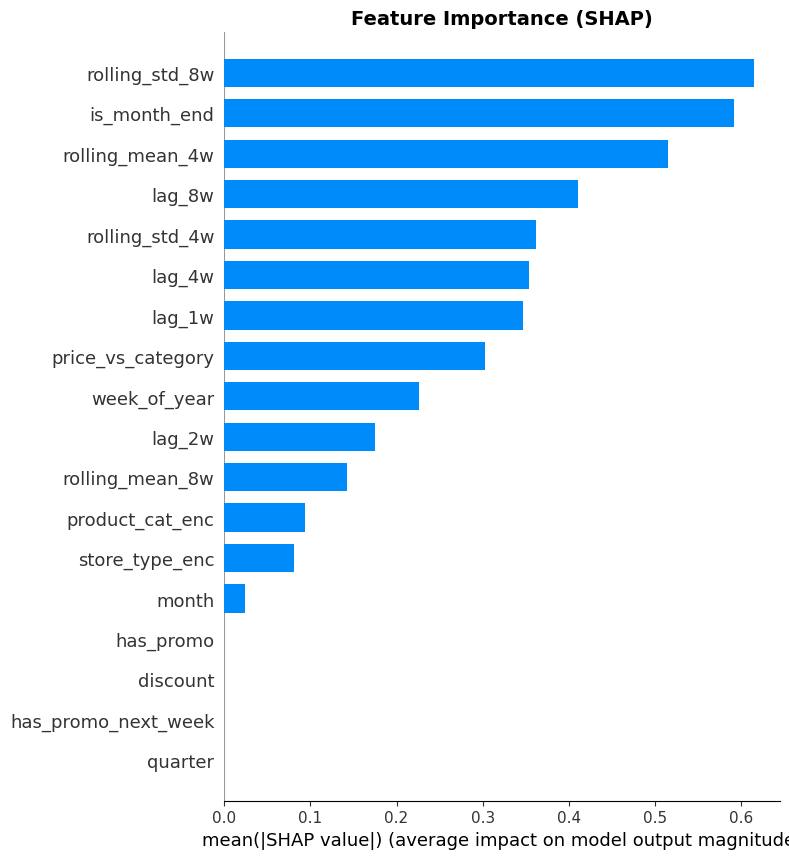


Top 5 most important features:
        feature  importance
 rolling_std_8w    0.614336
   is_month_end    0.591097
rolling_mean_4w    0.514564
         lag_8w    0.410752
 rolling_std_4w    0.361558


In [4]:
explainer  = shap.TreeExplainer(model_m1)
shap_vals  = explainer.shap_values(X_val)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_val, feature_names=FEATURE_COLS, 
                  plot_type='bar', show=False)
plt.title("Feature Importance (SHAP)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150, bbox_inches='tight')
plt.show()

# Top 5 features
shap_df = pd.DataFrame({'feature': FEATURE_COLS,
                         'importance': np.abs(shap_vals).mean(0)})
shap_df = shap_df.sort_values('importance', ascending=False)
print("\nTop 5 most important features:")
print(shap_df.head(5).to_string(index=False))

## 4. Forecast vs Actual — Visual Validation

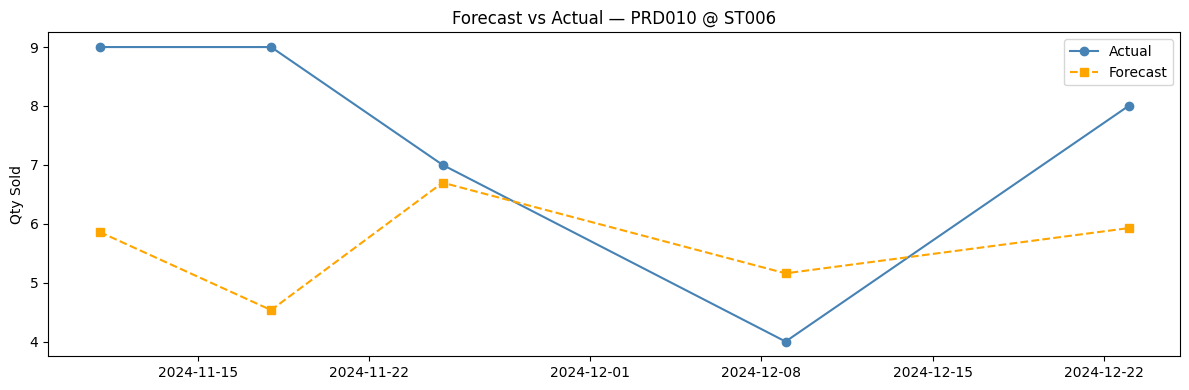

In [5]:
# เลือก 1 product-store คู่ มา plot
sample = test[test['product_id'] == test['product_id'].value_counts().index[0]]
sample = sample[sample['store_id'] == sample['store_id'].value_counts().index[0]]

if len(sample) > 0:
    s_pred = np.maximum(0, model_m1.predict(sample[FEATURE_COLS]))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(sample['week'], sample[TARGET_COL], 'o-', label='Actual', color='steelblue')
    ax.plot(sample['week'], s_pred, 's--', label='Forecast', color='orange')
    ax.set_title(f"Forecast vs Actual — {sample['product_id'].iloc[0]} @ {sample['store_id'].iloc[0]}")
    ax.legend()
    ax.set_ylabel('Qty Sold')
    plt.tight_layout()
    plt.savefig("forecast_vs_actual.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Not enough test data for this product-store pair")

## 5. M2 Lead Time Model

In [11]:
import os

In [12]:
import pandas as pd
import numpy as np

DATA_PATH = r"C:\Users\hp\Documents\GitHub\sme-retail-ds-solution\data\raw"
po       = pd.read_csv(os.path.join(DATA_PATH, "purchasing_order.csv"), parse_dates=["po_date","arrival_date","expire_date"])
products = pd.read_csv(os.path.join(DATA_PATH, "product_master.csv"))

po['lead_time_days'] = (po['arrival_date'] - po['po_date']).dt.days

po['lead_time_days'] = (po['arrival_date'] - po['po_date']).dt.days
po = po.merge(products[['product_id','product_taxonomies']], on='product_id', how='left')
po['po_month'] = po['po_date'].dt.month
po['po_dow']   = po['po_date'].dt.dayofweek
po['po_qty_log'] = np.log1p(po['qty'])

cat_map = {c: i for i, c in enumerate(po['product_taxonomies'].dropna().unique())}
wh_map  = {w: i for i, w in enumerate(po['warehouse_id'].unique())}
po['product_cat_enc'] = po['product_taxonomies'].map(cat_map)
po['warehouse_enc']   = po['warehouse_id'].map(wh_map)

LT_FEATURES = ['po_month','po_dow','po_qty_log','product_cat_enc','warehouse_enc']
lt_df = po.dropna(subset=LT_FEATURES + ['lead_time_days'])

# Simple time-based split
lt_train = lt_df[lt_df['po_date'] < '2024-10-01']
lt_test  = lt_df[lt_df['po_date'] >= '2024-10-01']

with mlflow.start_run(run_name="lgbm_lead_time_v1"):
    lt_params = {**params, 'objective':'regression', 'metric':'mae', 'n_estimators':200}
    model_m2 = lgb.LGBMRegressor(**lt_params)
    model_m2.fit(lt_train[LT_FEATURES], lt_train['lead_time_days'],
                 eval_set=[(lt_test[LT_FEATURES], lt_test['lead_time_days'])],
                 callbacks=[lgb.early_stopping(30, verbose=False)])

    lt_pred = model_m2.predict(lt_test[LT_FEATURES])
    mae = np.mean(np.abs(lt_test['lead_time_days'].values - lt_pred))
    mlflow.log_metric("test_mae_days", mae)
    mlflow.lightgbm.log_model(model_m2, "lead_time_model")
    print(f"Lead Time Model MAE: {mae:.2f} days  (target: < 1.5 days)")

2026/05/25 09:16:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 09:16:38 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lead Time Model MAE: 3.49 days  (target: < 1.5 days)


## 6. Save Models

In [13]:
import pickle, os
os.makedirs("models", exist_ok=True)

with open("models/model_m1_demand.pkl","wb") as f: pickle.dump(model_m1, f)
with open("models/model_m2_lead_time.pkl","wb") as f: pickle.dump(model_m2, f)

print("✅ Models saved:")
print("   models/model_m1_demand.pkl")
print("   models/model_m2_lead_time.pkl")
print("\n→ ขั้นตอนต่อไป: Notebook 04 — Co-optimization Engine")

✅ Models saved:
   models/model_m1_demand.pkl
   models/model_m2_lead_time.pkl

→ ขั้นตอนต่อไป: Notebook 04 — Co-optimization Engine
